<a href="https://colab.research.google.com/github/swanjala849-Mas/Machine-Learning/blob/main/Knn_Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, metrics, model_selection
sns.set_theme(style = "whitegrid")
np.random.seed(42)


In [ ]:
iris=datasets.load_iris(as_frame=True)
df=iris.frame
df.head()
print(df["target"].value_counts())
print(df.describe)

target
0    50
1    50
2    50
Name: count, dtype: int64
<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149               

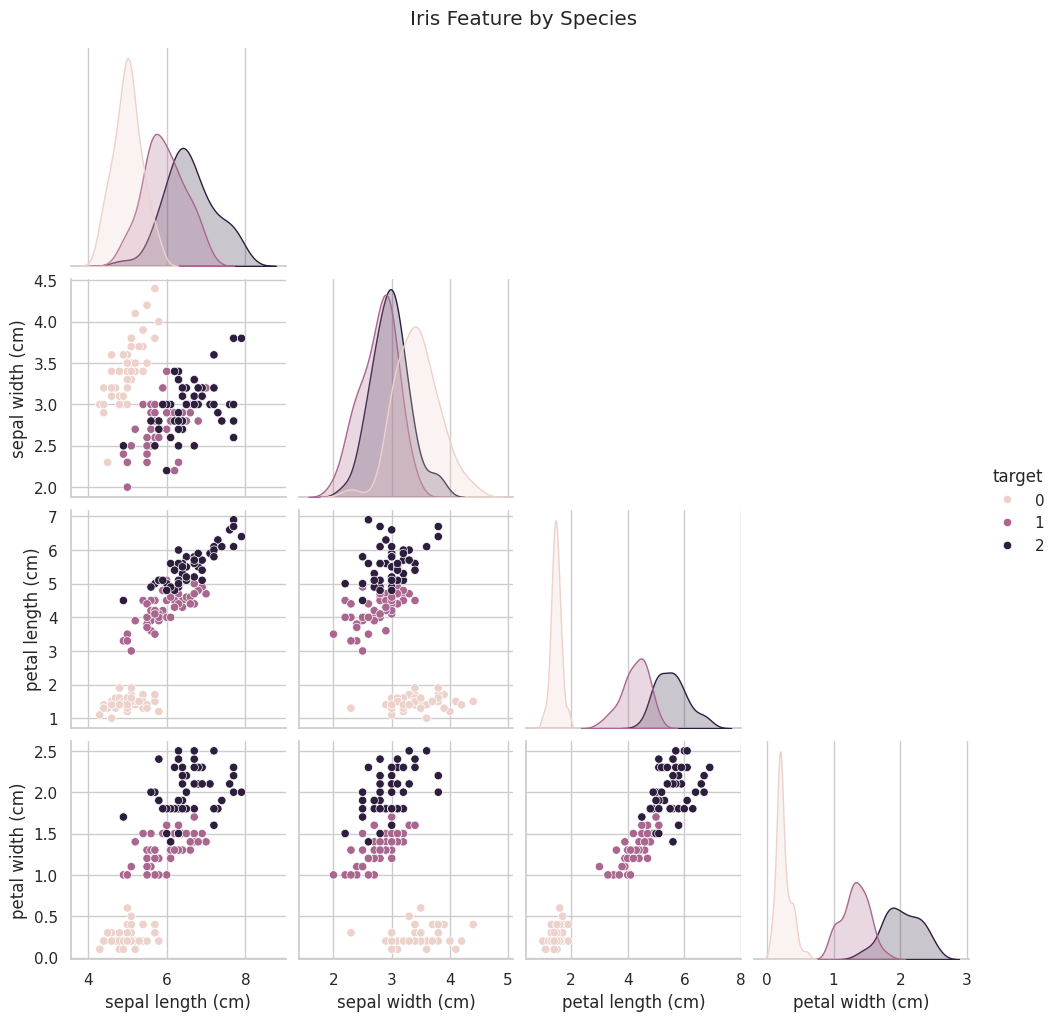

In [ ]:
sns.pairplot(df,hue='target',corner=True)
plt.suptitle('Iris Feature by Species', y=1.02)
plt.show()

In [ ]:
# Train
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

x = df.drop(columns=["target"])
y = df["target"]
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.25, random_state=42, stratify=y
)
dummy= DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print ('Dummy accuracy:'), accuracy_score(y_test, dummy.predict(x_test))


Dummy accuracy:


(None, 0.3157894736842105)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
knn = Pipeline([
    ('scale', StandardScaler()),
    ('clf', KNeighborsClassifier()),

])
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.92        38
weighted avg       0.94      0.92      0.92        38

[[12  0  0]
 [ 0 13  0]
 [ 0  3 10]]
